# Experimento 4 — Estatísticas agregadas pré-torneio

Features: **SeedDif, WinRateDiff, AvgPointsForDiff, AvgPointsAgainstDiff e OppWinRateDiff**.

Cada estatística usa a temporada regular **do próprio ano**, encerrada antes do NCAA
Tournament. “Anterior ao torneio” significa os jogos anteriores ao torneio naquela
temporada, não a temporada do ano anterior.

- WinRate: vitórias / jogos de toda a temporada regular.
- AvgPointsFor / AvgPointsAgainst: médias dos pontos marcados / sofridos por jogo,
  considerando corretamente vitórias e derrotas.
- OppWinRate: média do win rate completo dos adversários, com peso igual por partida.
  Reencontros contam novamente e não excluímos o confronto direto do win rate do adversário.
- Todas as diferenças seguem **A − B**, com A sendo o menor ID. As taxas individuais
  são intermediárias e não entram no modelo.

Mantemos os experimentos anteriores intactos. Resultados, gráficos e configurações
ficam neste notebook; somente os três CSVs de submissão são gravados fora dele.


## Configuração

Reutilizamos os criadores de modelos e a validação de `src/tuning.py`.
Busca: duas opções de intercepto na regressão linear e 30 trials para cada modelo de árvores,
nos mesmos espaços dos experimentos 2/3.

Validação expansiva: 2021–2025, sempre treinando em temporadas anteriores. Para 2021,
o último torneio de treino é 2019, pois não houve torneio em 2020.
O objetivo é a média simples dos cinco scores anuais combinados M/W. Masculino e
feminino são treinados separadamente, com a mesma configuração por família de modelo.

Esses anos selecionam os hiperparâmetros: não constituem um teste independente.
Nenhum score Kaggle participa da busca.


In [1]:
from pathlib import Path
import sys
import json
from importlib.metadata import version

import numpy as np
import pandas as pd
import optuna
from IPython.display import display

pasta_atual = Path.cwd().resolve()
raiz = next(
    (p for p in [pasta_atual, *pasta_atual.parents] if (p / "raw_data").is_dir()),
    None,
)
if raiz is None:
    raise FileNotFoundError("Pasta raw_data não encontrada.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.data_processing import carregar_dados, preparar_seeds, organizar_jogos
from src.features import adicionar_seeds, calcular_winrate, adicionar_winrate
from src.models import criar_regressao_linear, criar_random_forest, criar_xgboost
from src.tuning import otimizar_modelo
from src.submission import preparar_confrontos, prever_confrontos, salvar_submission

EXPERIMENTO = "exp4_features_agregadas"
FEATURES = ["SeedDif", "WinRateDiff", "AvgPointsForDiff", "AvgPointsAgainstDiff", "OppWinRateDiff"]
ANOS_VALIDACAO = list(range(2021, 2026))
TEMPORADA_PREVISAO = 2026
SEED = 42
N_JOBS_MODELO = 2
CATEGORIAS = {"M": "Masculino", "W": "Feminino"}
CRIADORES = {
    "linear": criar_regressao_linear,
    "random_forest": criar_random_forest,
    "xgboost": criar_xgboost,
}
NOMES = {"linear": "Regressão linear", "random_forest": "Random Forest", "xgboost": "XGBoost"}
N_TRIALS = {"linear": 2, "random_forest": 30, "xgboost": 30}
PARAMETROS_FIXOS = {
    "linear": {},
    "random_forest": {"random_state": SEED, "n_jobs": N_JOBS_MODELO},
    "xgboost": {
        "random_state": SEED, "n_jobs": N_JOBS_MODELO,
        "objective": "reg:squarederror", "tree_method": "hist",
    },
}
ESPACOS = {
    "linear": {
        "fit_intercept": {"tipo": "categorical", "choices": [False, True]},
    },
    "random_forest": {
        "n_estimators": {"tipo": "int", "low": 150, "high": 500, "step": 50},
        "max_depth": {"tipo": "categorical", "choices": [2, 3, 4, 6, 8, 12, None]},
        "min_samples_leaf": {"tipo": "int", "low": 2, "high": 80, "log": True},
        "max_features": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "max_samples": {"tipo": "float", "low": 0.6, "high": 1.0},
    },
    "xgboost": {
        "n_estimators": {"tipo": "int", "low": 100, "high": 600, "step": 50},
        "max_depth": {"tipo": "int", "low": 1, "high": 5},
        "learning_rate": {"tipo": "float", "low": 0.01, "high": 0.15, "log": True},
        "min_child_weight": {"tipo": "float", "low": 5.0, "high": 80.0, "log": True},
        "subsample": {"tipo": "float", "low": 0.6, "high": 1.0},
        "colsample_bytree": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "reg_alpha": {"tipo": "float", "low": 0.00001, "high": 10.0, "log": True},
        "reg_lambda": {"tipo": "float", "low": 0.1, "high": 100.0, "log": True},
        "gamma": {"tipo": "float", "low": 0.0, "high": 5.0},
    },
}
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.features import calcular_estatisticas_agregadas, adicionar_estatisticas
from src.tuning import avaliar_temporadas
LIMITE_DAYNUM_PREVISAO = 134

REFERENCIA_EXP2 = json.loads(r'''{"fonte":"notebooks/features_incrementais/seed_winrate.ipynb: registro do experimento","melhores_parametros":{"linear":{"fit_intercept":true},"random_forest":{"random_state":42,"n_jobs":2,"n_estimators":150,"max_depth":4,"min_samples_leaf":3,"max_features":0.5,"max_samples":0.7047788912373731},"xgboost":{"random_state":42,"n_jobs":2,"objective":"reg:squarederror","tree_method":"hist","n_estimators":350,"max_depth":1,"learning_rate":0.015533475780068709,"min_child_weight":28.39153426673116,"subsample":0.9278170389008983,"colsample_bytree":1.0,"reg_alpha":0.0005319035315579878,"reg_lambda":23.634061077276915,"gamma":3.1955045490327145}},"melhores_medias":{"linear":0.07418743848556919,"random_forest":0.0713975003431827,"xgboost":0.06982085421732384},"versoes":{"numpy":"2.2.6","pandas":"2.3.2","scikit-learn":"1.7.1","xgboost":"3.0.5","optuna":"4.9.0"}}''')


## Preparar dados e verificar separação temporal

Carregamos exclusivamente `M/WRegularSeasonCompactResults.csv` para calcular as estatísticas.
Os resultados NCAA servem para os targets, os cortes históricos por DayNum e auditoria;
nenhum placar do torneio entra no cálculo das features.

Para cada temporada histórica, o limite exclusivo é o primeiro DayNum do torneio
daquela categoria. Para 2026 usamos o mesmo limite dos notebooks anteriores: **DayNum < 134**.
As funções rejeitam jogos fora do recorte. Não descartamos silenciosamente jogos
históricos com features ausentes.


In [2]:
dados = {
    categoria: carregar_dados(raiz / "raw_data", categoria, incluir_regular=True)
    for categoria in CATEGORIAS
}
assert set(dados["M"]["times"]["TeamID"]).isdisjoint(set(dados["W"]["times"]["TeamID"]))
seeds, estatisticas, jogos, limites, auditoria = {}, {}, {}, {}, []
for categoria, base in dados.items():
    torneios = base["resultados"].loc[base["resultados"]["Season"] < TEMPORADA_PREVISAO].copy()
    limites[categoria] = torneios.groupby("Season")["DayNum"].min().to_dict()
    limites[categoria][TEMPORADA_PREVISAO] = LIMITE_DAYNUM_PREVISAO
    regulares = base["temporada_regular"].loc[
        base["temporada_regular"]["Season"].isin(limites[categoria])
    ].copy()
    assert (regulares["DayNum"] < regulares["Season"].map(limites[categoria])).all()
    assert regulares.merge(
        torneios[["Season", "DayNum", "WTeamID", "LTeamID"]],
        on=["Season", "DayNum", "WTeamID", "LTeamID"],
    ).empty, "Sobreposição entre jogos regulares e NCAA."
    ids_categoria = set(base["times"]["TeamID"])
    assert regulares["WTeamID"].isin(ids_categoria).all()
    assert regulares["LTeamID"].isin(ids_categoria).all()

    seeds[categoria] = preparar_seeds(base["seeds"])
    estatisticas[categoria] = calcular_estatisticas_agregadas(
        regulares, limites_daynum=limites[categoria],
    )
    # Compatibilidade do win rate de temporada inteira com o Experimento 2.
    taxas_antigas = calcular_winrate(regulares).set_index(["Season", "TeamID"])
    stats_index = estatisticas[categoria].set_index(["Season", "TeamID"])
    np.testing.assert_allclose(stats_index["WinRate"], taxas_antigas.loc[stats_index.index, "WinRate"])
    assert not estatisticas[categoria].duplicated(["Season", "TeamID"]).any()

    base_jogos = adicionar_seeds(organizar_jogos(torneios), seeds[categoria])
    jogos[categoria] = adicionar_estatisticas(base_jogos, estatisticas[categoria])
    tabela = jogos[categoria]
    assert len(tabela) == len(torneios)
    assert (tabela["TeamA"] < tabela["TeamB"]).all()
    assert tabela["Target"].equals(tabela["ScoreA"] - tabela["ScoreB"])
    assert tabela["SeedDif"].equals(tabela["SeedA"] - tabela["SeedB"])
    assert np.isfinite(tabela[FEATURES].to_numpy()).all()
    assert tabela["TeamA"].isin(ids_categoria).all() and tabela["TeamB"].isin(ids_categoria).all()
    for nome in ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]:
        chave_a = pd.MultiIndex.from_frame(tabela[["Season", "TeamA"]])
        chave_b = pd.MultiIndex.from_frame(tabela[["Season", "TeamB"]])
        esperado = stats_index[nome].reindex(chave_a).to_numpy() - stats_index[nome].reindex(chave_b).to_numpy()
        np.testing.assert_allclose(tabela[f"{nome}Diff"], esperado)

    for ano, grupo in regulares.groupby("Season"):
        auditoria.append({
            "Categoria": categoria, "Season": ano, "JogosRegulares": len(grupo),
            "UltimoDayNumRegular": grupo["DayNum"].max(), "LimiteExclusivo": limites[categoria][ano],
        })

auditoria = pd.DataFrame(auditoria)
display(auditoria.loc[auditoria["Season"] >= min(ANOS_VALIDACAO)])
divisoes = pd.DataFrame([
    {
        "AnoValidacao": ano, "Categoria": CATEGORIAS[categoria],
        "UltimoAnoTreino": tabela.loc[tabela["Season"] < ano, "Season"].max(),
        "JogosTreino": tabela["Season"].lt(ano).sum(),
        "JogosValidacao": tabela["Season"].eq(ano).sum(),
    }
    for ano in ANOS_VALIDACAO for categoria, tabela in jogos.items()
])
assert divisoes["JogosValidacao"].gt(0).all()
assert (divisoes["UltimoAnoTreino"] < divisoes["AnoValidacao"]).all()
assert divisoes.loc[divisoes["AnoValidacao"].eq(2021), "UltimoAnoTreino"].eq(2019).all()
display(divisoes)
display(jogos["M"][["Season", "TeamA", "TeamB", *FEATURES, "Target"]].head())


,Categoria,Season,JogosRegulares,UltimoDayNumRegular,LimiteExclusivo
35,M,2021,3855,132,136
36,M,2022,5345,132,134
37,M,2023,5602,132,134
38,M,2024,5607,132,134
39,M,2025,5641,132,134
40,M,2026,5647,132,134
63,W,2021,3556,132,139
64,W,2022,5060,132,135
65,W,2023,5374,132,135
66,W,2024,5414,132,135


,AnoValidacao,Categoria,UltimoAnoTreino,JogosTreino,JogosValidacao
0,2021,Masculino,2019,2251,66
1,2021,Feminino,2019,1386,63
2,2022,Masculino,2021,2317,67
3,2022,Feminino,2021,1449,67
4,2023,Masculino,2022,2384,67
5,2023,Feminino,2022,1516,67
6,2024,Masculino,2023,2451,67
7,2024,Feminino,2023,1583,67
8,2025,Masculino,2024,2518,67
9,2025,Feminino,2024,1650,67


,Season,TeamA,TeamB,SeedDif,WinRateDiff,AvgPointsForDiff,AvgPointsAgainstDiff,OppWinRateDiff,Target
0,1985,1116,1234,1,-0.030303,-4.400000,2.430303,0.020862,9
1,1985,1120,1345,5,-0.059310,1.224828,1.335172,0.002403,1
2,1985,1207,1250,-15,0.546616,9.982120,-10.132822,0.131907,25
3,1985,1229,1425,1,0.062169,3.199735,1.022487,-0.033687,3
4,1985,1242,1325,-11,0.025926,8.477778,7.400000,0.065588,11


## Análise descritiva antes do treino

Estatísticas básicas e correlações de Pearson por categoria, somente nos jogos históricos
até 2025. O alvo não entra na matriz. Reportamos NaNs e infinitos explicitamente.

A correlação é descritiva dos confrontos (times podem aparecer em vários jogos), não
demonstra causalidade ou utilidade preditiva. Como seed menor e win rate maior costumam
favorecer o mesmo time, seus sinais de diferença podem apresentar correlação negativa.


In [3]:
correlacoes = {}
for categoria, nome in CATEGORIAS.items():
    tabela = jogos[categoria][FEATURES]
    verificacao = pd.DataFrame({
        "NaNs": tabela.isna().sum(),
        "Infinitos": np.isinf(tabela.to_numpy()).sum(axis=0),
    }, index=FEATURES)
    assert verificacao.to_numpy().sum() == 0
    print(nome)
    display(verificacao)
    display(tabela.describe().T.round(4))
    correlacoes[categoria] = tabela.corr()
    display(correlacoes[categoria].round(3))
    print(f"Correlação SeedDif × WinRateDiff: {correlacoes[categoria].loc['SeedDif', 'WinRateDiff']:.3f}")


Masculino
Correlação SeedDif × WinRateDiff: -0.604
Feminino
Correlação SeedDif × WinRateDiff: -0.568


,NaNs,Infinitos
SeedDif,0,0
WinRateDiff,0,0
AvgPointsForDiff,0,0
AvgPointsAgainstDiff,0,0
OppWinRateDiff,0,0


,count,mean,std,min,25%,50%,75%,max
SeedDif,2585.0,-0.1605,7.5311,-15.0000,-5.0000,0.0000,5.0000,15.0000
WinRateDiff,2585.0,0.0029,0.1507,-0.6333,-0.0938,0.0060,0.1013,0.6116
AvgPointsForDiff,2585.0,0.9084,8.4422,-52.9464,-4.2276,0.9811,6.3462,45.2857
AvgPointsAgainstDiff,2585.0,0.3522,6.9391,-47.3795,-3.9562,0.2680,4.7405,37.4286
OppWinRateDiff,2585.0,0.0007,0.0742,-0.2315,-0.0444,0.0001,0.0482,0.2216


,SeedDif,WinRateDiff,AvgPointsForDiff,AvgPointsAgainstDiff,OppWinRateDiff
SeedDif,1.000,-0.604,-0.412,0.148,-0.728
WinRateDiff,-0.604,1.000,0.461,-0.271,0.064
AvgPointsForDiff,-0.412,0.461,1.000,0.616,0.183
AvgPointsAgainstDiff,0.148,-0.271,0.616,1.000,0.023
OppWinRateDiff,-0.728,0.064,0.183,0.023,1.000


,NaNs,Infinitos
SeedDif,0,0
WinRateDiff,0,0
AvgPointsForDiff,0,0
AvgPointsAgainstDiff,0,0
OppWinRateDiff,0,0


,count,mean,std,min,25%,50%,75%,max
SeedDif,1717.0,0.2033,7.3668,-15.0000,-5.0000,1.0000,5.0000,15.0000
WinRateDiff,1717.0,0.0090,0.1641,-0.4688,-0.1038,0.0119,0.1201,0.5484
AvgPointsForDiff,1717.0,0.9810,9.0632,-30.8485,-5.2226,0.9250,6.9688,29.4242
AvgPointsAgainstDiff,1717.0,-0.2798,6.9066,-29.9615,-4.8621,-0.2806,4.4403,27.8095
OppWinRateDiff,1717.0,-0.0060,0.0861,-0.2734,-0.0635,-0.0066,0.0484,0.2850


,SeedDif,WinRateDiff,AvgPointsForDiff,AvgPointsAgainstDiff,OppWinRateDiff
SeedDif,1.000,-0.568,-0.581,0.181,-0.798
WinRateDiff,-0.568,1.000,0.612,-0.468,0.173
AvgPointsForDiff,-0.581,0.612,1.000,0.184,0.369
AvgPointsAgainstDiff,0.181,-0.468,0.184,1.000,0.031
OppWinRateDiff,-0.798,0.173,0.369,0.031,1.000


## Optuna — Experimento 4

Cada tentativa faz dez ajustes: duas categorias × cinco anos. Todas avaliam todos
os anos, sem pruning. A configuração vencedora é reavaliada pelo módulo de tuning.
As tentativas ficam acessíveis em memória em `buscas[nome]["estudo"]`.


In [4]:
buscas = {}
for nome, criar_modelo in CRIADORES.items():
    sampler = (
        optuna.samplers.GridSampler({"fit_intercept": [False, True]}, seed=SEED)
        if nome == "linear" else optuna.samplers.TPESampler(seed=SEED)
    )
    buscas[nome] = otimizar_modelo(
        jogos, criar_modelo, ESPACOS[nome], ANOS_VALIDACAO,
        features=FEATURES, n_trials=N_TRIALS[nome],
        parametros_fixos=PARAMETROS_FIXOS[nome], sampler=sampler,
        seed=SEED, nome=f"exp4_{nome}",
    )

resumo = pd.DataFrame([
    {
        "Modelo": NOMES[nome], "MediaLogisticBrier": resultado["media"],
        "MelhorTrial": resultado["estudo"].best_trial.number,
        "Tentativas": len(resultado["estudo"].trials),
        "Parametros": json.dumps(resultado["parametros"], ensure_ascii=False),
    }
    for nome, resultado in buscas.items()
]).sort_values("MediaLogisticBrier")
display(resumo)
for nome, resultado in buscas.items():
    print(NOMES[nome], resultado["parametros"])


exp4_linear: 2/2; melhor média = 0.071026
exp4_random_forest: 5/30; melhor média = 0.069237
exp4_random_forest: 10/30; melhor média = 0.069023
exp4_random_forest: 15/30; melhor média = 0.068681
exp4_random_forest: 20/30; melhor média = 0.068681
exp4_random_forest: 25/30; melhor média = 0.068681
exp4_random_forest: 30/30; melhor média = 0.068681
exp4_xgboost: 5/30; melhor média = 0.067620
exp4_xgboost: 10/30; melhor média = 0.067620
exp4_xgboost: 15/30; melhor média = 0.067620
exp4_xgboost: 20/30; melhor média = 0.067620
exp4_xgboost: 25/30; melhor média = 0.067568
exp4_xgboost: 30/30; melhor média = 0.067568
Regressão linear {'fit_intercept': True}
Random Forest {'random_state': 42, 'n_jobs': 2, 'n_estimators': 500, 'max_depth': 4, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_samples': 0.6065760550178787}
XGBoost {'random_state': 42, 'n_jobs': 2, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.012689764289026415, 'min_

,Modelo,MediaLogisticBrier,MelhorTrial,Tentativas,Parametros
2,XGBoost,0.067568,22,30,"{""random_state"": 42, ""n_jobs"": 2, ""objective"":..."
1,Random Forest,0.068681,12,30,"{""random_state"": 42, ""n_jobs"": 2, ""n_estimator..."
0,Regressão linear,0.071026,0,2,"{""fit_intercept"": true}"


## Scores anuais e comparação com os experimentos anteriores

Recalculamos o baseline original (regressão linear sem intercepto, somente SeedDif)
nos mesmos cinco anos. Para o Experimento 2, usamos uma cópia explícita dos parâmetros
vencedores registrados no seu notebook e recalculamos os scores com as mesmas divisões;
não executamos nem modificamos aquele notebook.

O baseline original só tinha regressão linear; não inventamos scores de outros modelos.
Esta comparação inclui mudanças de configuração, além das features. Não é uma ablação
com hiperparâmetros fixos. Todos os números abaixo são de validação, não do Kaggle.


In [5]:
baseline = avaliar_temporadas(
    jogos, criar_regressao_linear(fit_intercept=False), ANOS_VALIDACAO, features=["SeedDif"],
)
comparacao_exp2 = {
    nome: avaliar_temporadas(
        jogos, CRIADORES[nome](**params), ANOS_VALIDACAO, features=["SeedDif", "WinRateDiff"],
    )
    for nome, params in REFERENCIA_EXP2["melhores_parametros"].items()
}
for nome, resultado in comparacao_exp2.items():
    np.testing.assert_allclose(resultado["media"], REFERENCIA_EXP2["melhores_medias"][nome], rtol=1e-6)

comparacao = pd.DataFrame(
    [{"Experimento": "Baseline: seed", "Modelo": NOMES["linear"], "MediaLogisticBrier": baseline["media"]}]
    + [
        {"Experimento": "Exp. 2: seed + win rate", "Modelo": NOMES[nome], "MediaLogisticBrier": resultado["media"]}
        for nome, resultado in comparacao_exp2.items()
    ]
    + [
        {"Experimento": "Exp. 4: agregadas", "Modelo": NOMES[nome], "MediaLogisticBrier": resultado["media"]}
        for nome, resultado in buscas.items()
    ]
)
display(comparacao.pivot(index="Modelo", columns="Experimento", values="MediaLogisticBrier").round(6))
ganhos = pd.DataFrame([
    {
        "Modelo": NOMES[nome], "Exp2": comparacao_exp2[nome]["media"],
        "Exp4": resultado["media"], "GanhoExp4": comparacao_exp2[nome]["media"] - resultado["media"],
    }
    for nome, resultado in buscas.items()
])
display(ganhos.round(6))
print("GanhoExp4 positivo indica redução do erro frente ao Exp. 2.")

scores_anuais = pd.concat([
    resultado["resultados"].assign(Modelo=NOMES[nome])
    for nome, resultado in buscas.items()
], ignore_index=True)
display(scores_anuais.pivot(index=["Season", "Categoria"], columns="Modelo", values="Score").round(6))
display(pd.DataFrame({
    "Baseline linear": baseline["resultados"].query("Categoria == 'Combinado'").set_index("Season")["Score"],
    **{
        f"Exp2 {NOMES[nome]}": resultado["resultados"].query("Categoria == 'Combinado'").set_index("Season")["Score"]
        for nome, resultado in comparacao_exp2.items()
    },
}).round(6))


GanhoExp4 positivo indica redução do erro frente ao Exp. 2.


Experimento,Baseline: seed,Exp. 2: seed + win rate,Exp. 4: agregadas
Modelo,,,
Random Forest,NaN,0.071398,0.068681
Regressão linear,0.074828,0.074187,0.071026
XGBoost,NaN,0.069821,0.067568


,Modelo,Exp2,Exp4,GanhoExp4
0,Regressão linear,0.074187,0.071026,0.003161
1,Random Forest,0.071398,0.068681,0.002716
2,XGBoost,0.069821,0.067568,0.002253


Modelo            Random Forest  Regressão linear   XGBoost
Season Categoria                                           
2021   Combinado       0.082348          0.089326  0.081031
       M               0.094469          0.099547  0.089541
       W               0.069651          0.078619  0.072115
2022   Combinado       0.077747          0.077999  0.073609
       M               0.081181          0.090219  0.079183
       W               0.074312          0.065780  0.068034
2023   Combinado       0.076542          0.078583  0.072668
       M               0.085649          0.089158  0.082475
       W               0.067434          0.068007  0.062862
2024   Combinado       0.054362          0.060232  0.057005
       M               0.071781          0.080869  0.074808
       W               0.036943          0.039594  0.039202
2025   Combinado       0.052409          0.048993  0.053528
       M               0.054630          0.053668  0.055949
       W               0.050187          0.044317  0.051107

,Baseline linear,Exp2 Regressão linear,Exp2 Random Forest,Exp2 XGBoost
Season,,,,
2021,0.085217,0.089430,0.085356,0.081805
2022,0.093686,0.087831,0.080982,0.081945
2023,0.079306,0.077149,0.076038,0.074626
2024,0.061754,0.060969,0.057411,0.056510
2025,0.054175,0.055558,0.057201,0.054219


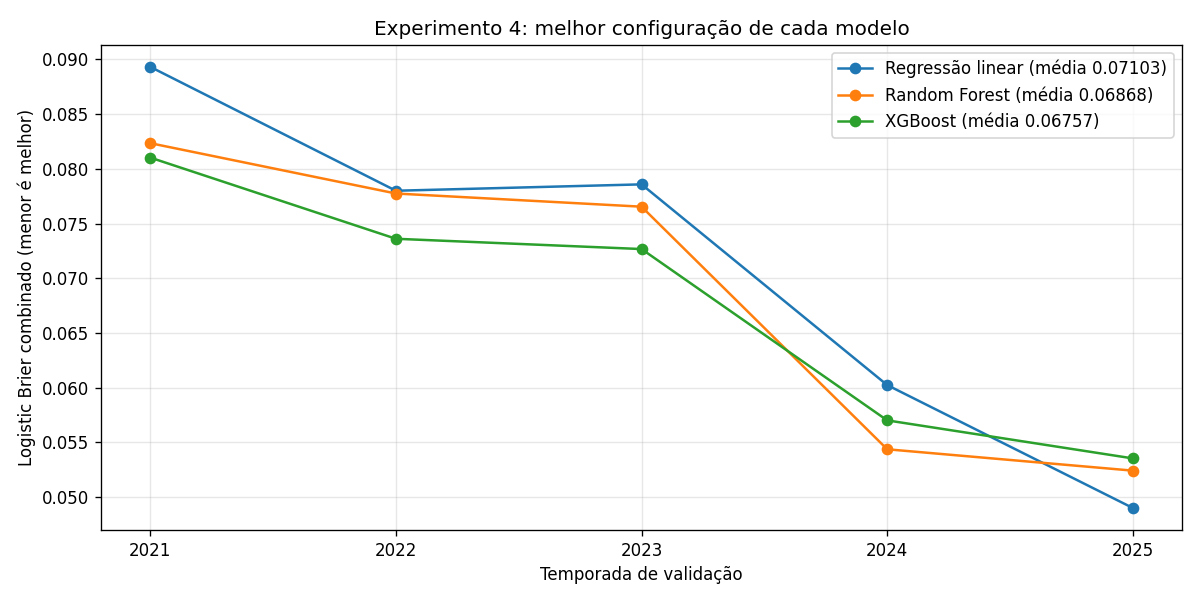

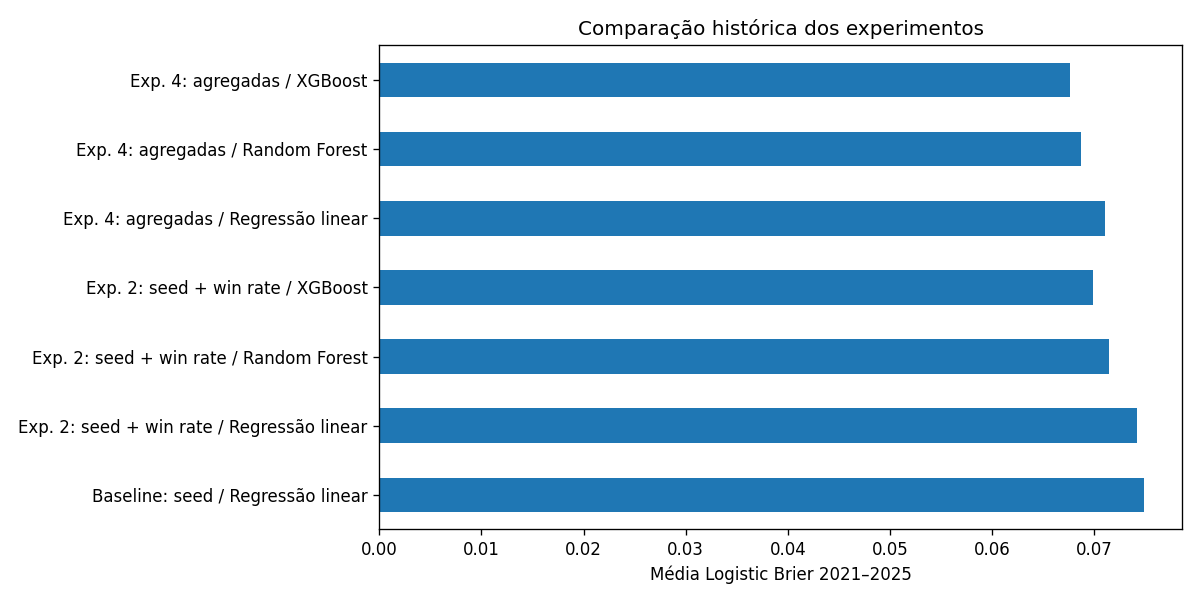

In [6]:
import matplotlib.pyplot as plt

fig_anos, ax = plt.subplots(figsize=(10, 5))
for nome, resultado in buscas.items():
    anual = resultado["resultados"].query("Categoria == 'Combinado'")
    ax.plot(anual["Season"], anual["Score"], marker="o", label=f"{NOMES[nome]} (média {resultado['media']:.5f})")
ax.set_title("Experimento 4: melhor configuração de cada modelo")
ax.set_xlabel("Temporada de validação")
ax.set_ylabel("Logistic Brier combinado (menor é melhor)")
ax.set_xticks(ANOS_VALIDACAO)
ax.grid(alpha=0.3)
ax.legend()
fig_anos.tight_layout()
plt.show()

fig_comparacao, ax = plt.subplots(figsize=(10, 5))
comparacao.assign(Rotulo=lambda t: t["Experimento"] + " / " + t["Modelo"]).plot.barh(
    x="Rotulo", y="MediaLogisticBrier", ax=ax, legend=False,
)
ax.set_xlabel("Média Logistic Brier 2021–2025")
ax.set_ylabel("")
ax.set_title("Comparação histórica dos experimentos")
fig_comparacao.tight_layout()
plt.show()


## Treino final e submissões de 2026

Treinamos novamente cada família e categoria com todo o histórico até 2025 e os
parâmetros selecionados. As estatísticas de 2026 vêm exclusivamente da temporada
regular de 2026 antes do limite.

Somente pares sem duas seeds podem usar o fallback zero. Qualquer feature ausente
entre dois participantes interrompe a execução. Verificamos IDs, ordem, finitude
e diferenças A − B. O CSV contém margens brutas, sem sigmoid.


In [7]:
sample_submission = dados["M"]["sample_submission"]
confrontos = preparar_confrontos(
    sample_submission, seeds["M"], seeds["W"],
    dados["M"]["times"]["TeamID"], dados["W"]["times"]["TeamID"],
    temporada=TEMPORADA_PREVISAO,
)
stats_2026 = pd.concat([
    stats.loc[stats["Season"].eq(TEMPORADA_PREVISAO)]
    for stats in estatisticas.values()
], ignore_index=True)
confrontos = adicionar_estatisticas(confrontos, stats_2026, permitir_ausentes=True)
participantes = confrontos["TemDuasSeeds"]
assert (confrontos["TeamA"] < confrontos["TeamB"]).all()
assert np.isfinite(confrontos.loc[participantes, FEATURES].to_numpy()).all()
stats_index = stats_2026.set_index(["Season", "TeamID"])
for nome in ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]:
    pares = confrontos.loc[participantes]
    a = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamA"]])).to_numpy()
    b = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamB"]])).to_numpy()
    np.testing.assert_allclose(pares[f"{nome}Diff"], a - b)

modelos_finais, arquivos_submission, resumo_submissions = {}, {}, []
for nome, criar_modelo in CRIADORES.items():
    modelos_finais[nome] = {}
    for categoria, tabela in jogos.items():
        treino = tabela.loc[tabela["Season"] < TEMPORADA_PREVISAO]
        assert treino["Season"].max() == 2025
        assert treino["TeamA"].isin(dados[categoria]["times"]["TeamID"]).all()
        assert treino["TeamB"].isin(dados[categoria]["times"]["TeamID"]).all()
        modelo = criar_modelo(**buscas[nome]["parametros"])
        modelo.fit(treino[FEATURES], treino["Target"])
        modelos_finais[nome][categoria] = modelo
    assert modelos_finais[nome]["M"] is not modelos_finais[nome]["W"]
    previsoes = prever_confrontos(
        confrontos, modelos_finais[nome]["M"], modelos_finais[nome]["W"], features=FEATURES,
    )
    assert previsoes.loc[~participantes, "Pred"].eq(0).all()
    assert previsoes["ID"].equals(sample_submission["ID"])
    caminho = salvar_submission(
        previsoes, sample_submission,
        raiz / "submissions" / f"submission_exp4_features_{nome}_{TEMPORADA_PREVISAO}.csv",
    )
    arquivos_submission[nome] = caminho
    resumo_submissions.append({
        "Modelo": NOMES[nome], "Arquivo": caminho.name,
        "Linhas": len(previsoes), "ParesParticipantes": int(participantes.sum()),
        "MinPred": previsoes["Pred"].min(), "MaxPred": previsoes["Pred"].max(),
    })
display(pd.DataFrame(resumo_submissions))


,Modelo,Arquivo,Linhas,ParesParticipantes,MinPred,MaxPred
0,Regressão linear,submission_exp4_features_linear_2026.csv,132133,4556,-50.549726,55.685852
1,Random Forest,submission_exp4_features_random_forest_2026.csv,132133,4556,-37.450187,43.802047
2,XGBoost,submission_exp4_features_xgboost_2026.csv,132133,4556,-31.225052,35.340015


## Registro do experimento

O registro abaixo permanece na saída do notebook, junto com as tabelas e os gráficos.
Não criamos arquivos extras de resultados. As submissões são arquivos locais; não
há envio automático ao Kaggle.

A média de pontos não é ajustada por ritmo, adversário ou prorrogação. OppWinRate é
uma aproximação simples do calendário, não uma avaliação completa de força dos times.


In [8]:
registro = {
    "experimento": EXPERIMENTO, "features": FEATURES, "anos_validacao": ANOS_VALIDACAO,
    "temporada_previsao": TEMPORADA_PREVISAO, "limite_daynum_2026": LIMITE_DAYNUM_PREVISAO,
    "objetivo": "Media simples dos scores anuais combinados M/W",
    "seed": SEED, "n_trials": N_TRIALS, "espacos_busca": ESPACOS,
    "parametros_fixos": PARAMETROS_FIXOS,
    "melhores_parametros": {nome: r["parametros"] for nome, r in buscas.items()},
    "melhores_medias": {nome: r["media"] for nome, r in buscas.items()},
    "scores_anuais": scores_anuais.to_dict(orient="records"),
    "comparacao": comparacao.to_dict(orient="records"),
    "referencia_exp2": REFERENCIA_EXP2,
    "versoes": {p: version(p) for p in ["numpy", "pandas", "scikit-learn", "xgboost", "optuna"]},
    "arquivos_submission": {nome: str(path.relative_to(raiz)) for nome, path in arquivos_submission.items()},
}
display(registro)


{'experimento': 'exp4_features_agregadas',
 'features': ['SeedDif',
  'WinRateDiff',
  'AvgPointsForDiff',
  'AvgPointsAgainstDiff',
  'OppWinRateDiff'],
 'anos_validacao': [2021, 2022, 2023, 2024, 2025],
 'temporada_previsao': 2026,
 'limite_daynum_2026': 134,
 'objetivo': 'Media simples dos scores anuais combinados M/W',
 'seed': 42,
 'n_trials': {'linear': 2, 'random_forest': 30, 'xgboost': 30},
 'espacos_busca': {'linear': {'fit_intercept': {'tipo': 'categorical',
    'choices': [False, True]}},
  'random_forest': {'n_estimators': {'tipo': 'int',
    'low': 150,
    'high': 500,
    'step': 50},
   'max_depth': {'tipo': 'categorical', 'choices': [2, 3, 4, 6, 8, 12, None]},
   'min_samples_leaf': {'tipo': 'int', 'low': 2, 'high': 80, 'log': True},
   'max_features': {'tipo': 'categorical', 'choices': [0.5, 1.0]},
   'max_samples': {'tipo': 'float', 'low': 0.6, 'high': 1.0}},
  'xgboost': {'n_estimators': {'tipo': 'int',
    'low': 100,
    'high': 600,
    'step': 50},
   'max_depth